In [2]:
import os
import glob

import numpy as np
import pandas as pd

from tator_tools.download_query import QueryDownloader
from tator_tools.yolo_dataset import YOLODataset
from tator_tools.download_rf_dataset import RoboflowDatasetDownloader

# Download Query from Tator

In [3]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 70  # 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IiR0eXBlIiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjUwMH1dfV19"

# Demo for downloading labeled data
frac = 1.0

dataset_name = "DebrisFinder"
output_dir = "../Data"

label_field = "MarineDebris"

In [4]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=label_field)

NOTE: Authentication successful for jordan.pierce
NOTE: Search string saved to e:\tator-tools\Data\DebrisFinder\search_string.txt


In [5]:
# Download the labeled data
downloader.download_data()

NOTE: Querying Tator for labeled data
NOTE: Found 944 objects in query


Processing query: 100%|██████████| 944/944 [00:00<00:00, 27763.41it/s]


NOTE: Found 944 query objects after sampling
NOTE: Data saved to e:\tator-tools\Data\DebrisFinder\data.csv
NOTE: Data saved to e:\tator-tools\Data\DebrisFinder\data.json
NOTE: Downloading images to e:\tator-tools\Data\DebrisFinder\images


NOTE: Images downloaded to e:\tator-tools\Data\DebrisFinder\images


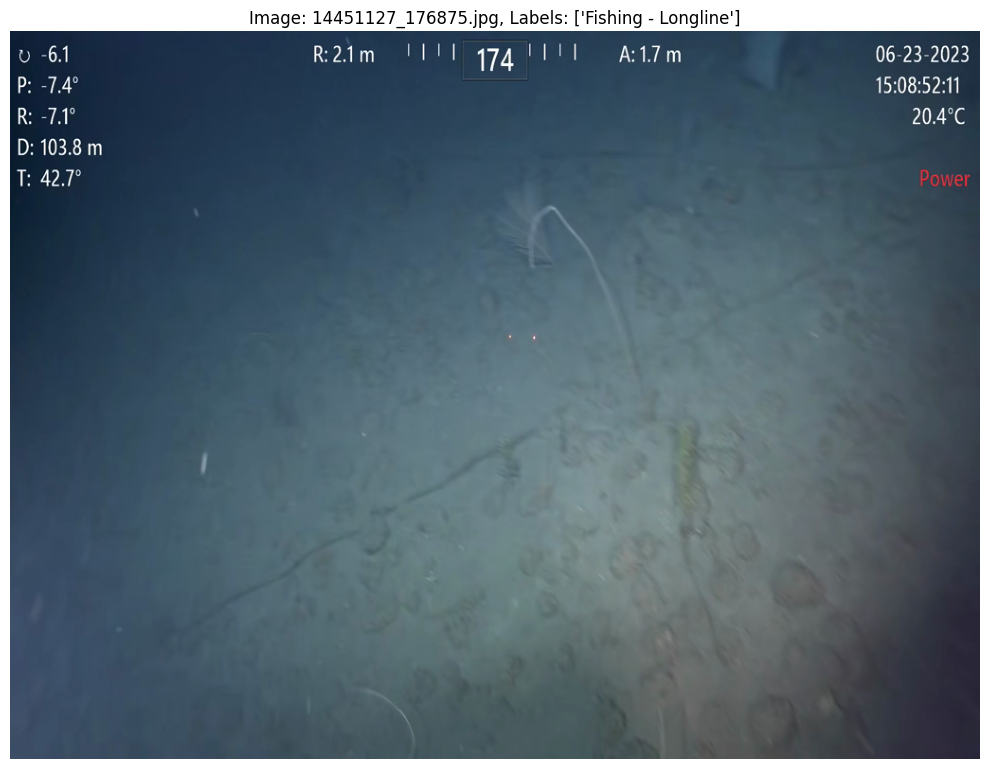

In [6]:
downloader.display_sample()

In [7]:
df = downloader.as_dataframe()  # .as_dict()

# Do some data exploration, filtering as needed
# Example: Drop all rows where x, y, width, or height is NaN
# df = df.dropna(subset=["x", "y", "width", "height"])
print(df.shape, df['image_name'].unique().shape)

(944, 12) (880,)


In [7]:
# Rename all of the classes
df["label"] = 'trash'


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Convert Data into YOLO-formatted Dataset

In [8]:
# Set parameters
output_dir = f"{output_dir}/{dataset_name}"
yolo_name = "YOLO_Dataset_MDBC_Relabeled_Trash"

train_ratio = 0.8
test_ratio = 0.1

task = 'detect' # 'detect' or 'segment'

In [9]:
# Create and process dataset
dataset = YOLODataset(
    data=df,
    output_dir=output_dir,
    dataset_name=yolo_name,
    train_ratio=train_ratio,
    test_ratio=test_ratio,
    task=task,
    format_class_names=True, 
)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [10]:
# Process the dataset
dataset.process_dataset(move_images=False)  # Makes a copy of the images instead of moving them

Processing YOLO dataset with 406 annotations...



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Dataset split: 282 train, 36 valid, 35 test images


Writing detection labels:   0%|          | 0/353 [00:00<?, ?it/s]

Copying images:   0%|          | 0/353 [00:00<?, ?it/s]

Dataset created at e:\tator-tools\Data\DebrisFinder\YOLO_Dataset_MDBC_Relabeled_Trash
Classes: ['trash']


Rendering Examples:   0%|          | 0/10 [00:00<?, ?it/s]

Rendered 10 examples to e:\tator-tools\Data\DebrisFinder\YOLO_Dataset_MDBC_Relabeled_Trash\examples


In [ ]:
dataset.dataset_dir

### Download RF Datasets

In [ ]:
downloader = RoboflowDatasetDownloader(api_key=os.getenv("ROBOFLOW_API_KEY"))

In [ ]:
urls = [
    "https://universe.roboflow.com/debris/deep-sea-debris-detection-dataset/dataset/1",
    "https://universe.roboflow.com/plastic-c1ye3/bharath/dataset/1",
    "https://universe.roboflow.com/underwater-ztbtg/thesis-rkzov/dataset/9",
    "https://universe.roboflow.com/object-detection-vtdep/trashcan_val/dataset/1"
]

In [ ]:
output_dir = "../Data/DebrisFinder/Roboflow_Raw"

# Choose download method based on input type
dataset = downloader.download_from_url(
    url=urls[3],
    output_dir=output_dir,
)

In [ ]:
ds = downloader.get_supervision_dataset()

In [ ]:
# Map all classes to "trash"
classes = ["trash" if "trash" in label.lower() else "drop" for label in ds.classes]
selected_classes = [v for v in range(len(classes)) if classes[v] == "trash"]
print(f"Original classes: {ds.classes}")
print(f"Mapped classes: {classes}")
selected_classes

In [ ]:
for image_name, detections in ds.annotations.items():
    detections = detections[np.isin(detections.class_id, selected_classes)]

In [ ]:
ds.classes = ['trash']

In [ ]:
data_output_dir = f"../Data/DebrisFinder/YOLO_Dataset_{downloader.dataset.name.replace(' ', '_')}"

downloader.export_to_yolo(ds, output_dir=data_output_dir)